In [1]:
import pertpy as pt
import scanpy as sc
import pandas as pd
import pandas as pd
import pandas as pd
import scvi
# Load a sample dataset
mdata = pt.dt.papalexi_2021()



OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/s

In [2]:
adata=mdata["rna"]


In [3]:
mdata

MuData object with n_obs × n_vars = 20729 × 18776
  4 modalities
    rna:	20729 x 18649
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_GDO', 'nCount_ADT', 'nFeature_ADT', 'percent.mito', 'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'Phase'
      var:	'name'
    adt:	20729 x 4
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_GDO', 'nCount_ADT', 'nFeature_ADT', 'percent.mito', 'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'Phase'
      var:	'name'
    hto:	20729 x 12
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_GDO', 'nCount_ADT', 'nFeature_ADT', 'percent.mito', 'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'Phase'
      var:	'name'
    gdo:	20729 x 111
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_GDO', 'nCount_ADT', 'nFeature_ADT', 'percent.mito', 'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'Phase'
      var:	'name'

In [4]:
mdata.mod["gdo"]

AnnData object with n_obs × n_vars = 20729 × 111
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_GDO', 'nCount_ADT', 'nFeature_ADT', 'percent.mito', 'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'Phase'
    var: 'name'

In [5]:
gdo = mdata.mod["gdo"]

# Extract the guide count matrix
gdo.X

<20729x111 sparse matrix of type '<class 'numpy.float32'>'
	with 2300919 stored elements in Compressed Sparse Column format>

In [6]:
gdo = mdata.mod["gdo"]

# Extract the guide count matrix
guide_count_matrix = gdo.X


guide_count_df = pd.DataFrame(guide_count_matrix.toarray(), index=gdo.obs.index, columns=gdo.var.index)

print(guide_count_df)

index                eGFPg1  CUL3g1  CUL3g2  CUL3g3  CMTM6g1  CMTM6g2  \
index                                                                   
l1_AAACCTGAGCCAGAAC     1.0     1.0     1.0     1.0      1.0      1.0   
l1_AAACCTGAGTGGACGT     1.0     1.0     1.0     1.0      1.0      1.0   
l1_AAACCTGCATGAGCGA     1.0     1.0     1.0     1.0      1.0      1.0   
l1_AAACCTGTCTTGTCAT     1.0     1.0     1.0     1.0      1.0      1.0   
l1_AAACGGGAGAACAACT     1.0     1.0     1.0     1.0      1.0      1.0   
...                     ...     ...     ...     ...      ...      ...   
l8_TTTGTCAGTCACTTCC     1.0     1.0     1.0     1.0    177.0      2.0   
l8_TTTGTCAGTGACGGTA     1.0     1.0     1.0     1.0      1.0      1.0   
l8_TTTGTCAGTTCCACAA     1.0     1.0     1.0     1.0      1.0      1.0   
l8_TTTGTCATCACGCATA     1.0     1.0     1.0     1.0      1.0      1.0   
l8_TTTGTCATCTGTACGA     1.0     1.0     1.0     1.0      1.0      1.0   

index                CMTM6g3  NTg1  NTg2  NTg3  ..

In [7]:
guide_adata = sc.AnnData(X=guide_count_df.values)
guide_adata.obs.index = guide_count_df.index
guide_adata.var.index = guide_count_df.columns
guide_adata.obs['replicate'] = mdata["rna"].obs['replicate']
guide_adata.obs['Phase'] = mdata["rna"].obs['Phase']
guide_adata.obs['perturbation'] = mdata["rna"].obs['perturbation']
guide_adata.obs['guide']= mdata["rna"].obs['NT']
# Inspect the AnnData object
print(guide_adata)

AnnData object with n_obs × n_vars = 20729 × 111
    obs: 'replicate', 'Phase', 'perturbation', 'guide'


In [8]:
scvi.model.SCVI.setup_anndata(guide_adata)


In [9]:
scvi_ref = scvi.model.SCVI(
    guide_adata,
    use_layer_norm="both",
    use_batch_norm="none",
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)
scvi_ref.train()

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 386/386: 100%|███████████████████████████████████████████| 386/386 [03:59<00:00,  1.62it/s, v_num=1, train_loss_step=149, train_loss_epoch=146]

`Trainer.fit` stopped: `max_epochs=386` reached.


Epoch 386/386: 100%|███████████████████████████████████████████| 386/386 [03:59<00:00,  1.61it/s, v_num=1, train_loss_step=149, train_loss_epoch=146]


/var/folders/3k/yfw07yqn6nbdwjkxhf022b2m0000gn/T/ipykernel_77710/3873981612.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(guide_adata)


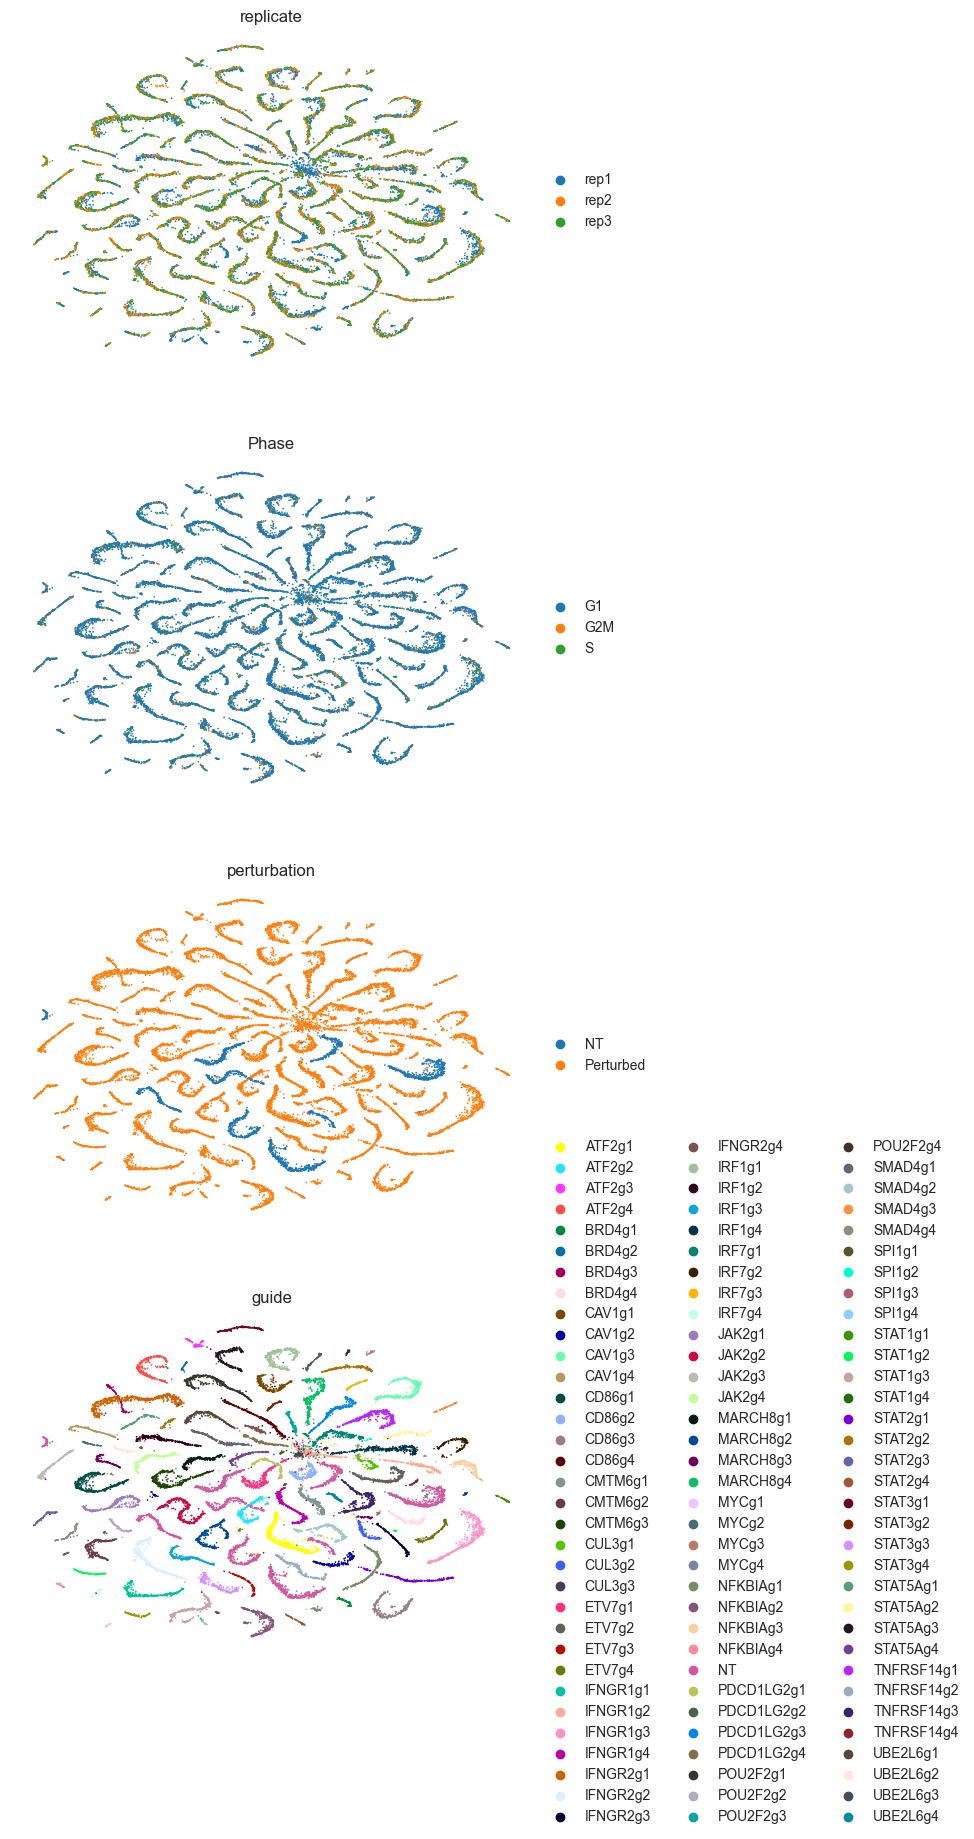

In [10]:
SCVI_LATENT_KEY = "X_scVI"

guide_adata.obsm[SCVI_LATENT_KEY] = scvi_ref.get_latent_representation()
sc.pp.neighbors(guide_adata, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(guide_adata)
sc.tl.umap(guide_adata)
sc.pl.umap(
    guide_adata,
    color=["replicate", "Phase", "perturbation","guide" ],
    frameon=False,
    ncols=1,
)

In [18]:
guide_adata.obs

,replicate,Phase,perturbation,_scvi_batch,_scvi_labels,leiden
index,,,,,,
l1_AAACCTGAGCCAGAAC,rep1,G1,Perturbed,0,0,26
l1_AAACCTGAGTGGACGT,rep1,G1,Perturbed,0,0,70
l1_AAACCTGCATGAGCGA,rep1,G1,Perturbed,0,0,79
l1_AAACCTGTCTTGTCAT,rep1,G1,Perturbed,0,0,6
l1_AAACGGGAGAACAACT,rep1,G1,Perturbed,0,0,60
...,...,...,...,...,...,...
l8_TTTGTCAGTCACTTCC,rep3,G1,Perturbed,0,0,35
l8_TTTGTCAGTGACGGTA,rep2,G1,NT,0,0,3
l8_TTTGTCAGTTCCACAA,rep3,G1,Perturbed,0,0,1
